In [1]:
# Patch asyncio to allow nested event loops.
# Required in Jupyter because ipykernel already runs an event loop, and
# several dependencies (wasmtime inside itkwasm/ngff-zarr, and some
# scikit-image C extensions) try to start their own loops at import time.
import nest_asyncio
nest_asyncio.apply()
print("nest_asyncio applied")

nest_asyncio applied


In [2]:
import sys
import matplotlib.pyplot as plt
import numpy as np

print("nest_asyncio applied")
print("Python executable:", sys.executable)
print("Python version:", sys.version)

%matplotlib inline

print("matplotlib OK")

nest_asyncio applied
Python executable: f:\Pixi_Projects\zen_czi\czitools\.pixi\envs\default\python.exe
Python version: 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:36:12) [MSC v.1944 64 bit (AMD64)]
matplotlib OK


In [3]:
# define file paths and parameters

hcs_omezarr_path: str = r"F:\Testdata_Zeiss\OME_ZARR_Testfiles\transloc_gfp_dapi_0_2micron_orig_HCSplate_zarr2.ome.zarr"
channel2analyze = 0  # Index of the channel to analyze
measure_properties = ("label", "area", "centroid", "bbox")

In [4]:
# this is the main function to process HCS OME-ZARR files
# feel free to adapt the actual processing steps as needed

def process_hcs_omezarr(
    hcs_omezarr_path: str, channel2analyze: int = 0, measure_properties=("label", "area", "centroid", "bbox")
):
    """
    Process an HCS OME-ZARR file to analyze wells and generate heatmaps.

    Parameters:
        hcs_omezarr_path (str): Path to the HCS OME-ZARR file.
        channel2analyze (int): Index of the channel to analyze.
    """

    # Lazy imports: these pull in heavy C extensions (wasmtime, skimage Cython
    # modules) that crash ipykernel when imported at kernel startup.
    # Importing inside the function is safe because the event loop is stable
    # by the time the function is first called.  Python caches modules after
    # the first import, so there is no repeated overhead.
    import ngff_zarr as nz
    from czitools.analysis_tools.processing import ArrayProcessor

    try:
        print("Validating created HCS-ZARR file against schema...")
        hcs_plate = nz.from_hcs_zarr(hcs_omezarr_path, validate=True)
        print("Validation successful.")
    except Exception as e:
        print(f"Validation failed: {e}")
        raise e

    # run some processing
    results_obj = {}
    results_mean = {}

    # Debug: Print plate metadata information
    print(f"Number of wells in metadata: {len(hcs_plate.metadata.wells)}")
    print(f"Wells in metadata: {[w.path for w in hcs_plate.metadata.wells]}")

    # Iterate through all wells that actually have data
    # Use the well path directly since it's always correct (e.g., "B/4")
    for well_meta in hcs_plate.metadata.wells:

        # Extract row and column from the path (format: "B/4")
        row, col = well_meta.path.split("/")
        print(f"\nProcessing well: {well_meta.path} (Row: {row}, Column: {col})")

        # Get the well object for the current row/column position
        well = hcs_plate.get_well(row, col)

        # Only process if the well exists and has data
        if not well:
            print(f"  Warning: Well {well_meta.path} not found in plate, skipping")
            continue

        if not well.images or len(well.images) == 0:
            print(f"  Warning: Well {well_meta.path} has no images, skipping")
            continue

        # Store intensities for all fields (positions) within the well
        field_intensities = []
        field_num_objects = []

        print(f"  Found {len(well.images)} field(s) in well {well_meta.path}")

        # Process each field (microscope position) in the current well
        for field_idx in range(len(well.images)):

            image = well.get_image(field_idx)

            if image:

                # Load the image data into memory (compute() for dask arrays)
                data = image.images[0].data.compute()
                print(
                    f"Processing well: {well_meta.path} - Field {field_idx} data shape: {data.shape}, dtype: {data.dtype}"
                )

                # count objects
                ap = ArrayProcessor(np.squeeze(data[:, channel2analyze, ...]))  # 2D data as input
                pro2d = ap.apply_otsu_threshold()
                ap = ArrayProcessor(pro2d)
                pro2d, num_objects, props = ap.label_objects(
                    min_size=100,
                    label_rgb=False,
                    orig_image=None,
                    bg_label=0,
                    measure_params=True,
                    measure_properties=measure_properties,
                )

                # store number of objects for this field
                field_num_objects.append(int(num_objects))

                # Calculate mean intensity for this field
                mean_intensity = np.mean(data)
                field_intensities.append(mean_intensity)

        # Store the average intensity across all fields for this well
        results_mean[f"{row}/{col}"] = np.mean(field_intensities)

        # Store the total number of objects across all fields for this well
        results_obj[f"{row}/{col}"] = np.sum(field_num_objects)

    # Report the number of wells processed
    print(f"Total Size of results: {len(results_mean)}")

    return results_obj


In [5]:
# Run the processing function and return results

results_obj = process_hcs_omezarr(
    hcs_omezarr_path=hcs_omezarr_path, channel2analyze=channel2analyze, measure_properties=measure_properties
)

Validating created HCS-ZARR file against schema...
Validation successful.
Number of wells in metadata: 96
Wells in metadata: ['A/01', 'A/02', 'A/03', 'A/04', 'A/05', 'A/06', 'A/07', 'A/08', 'A/09', 'A/10', 'A/11', 'A/12', 'B/01', 'B/02', 'B/03', 'B/04', 'B/05', 'B/06', 'B/07', 'B/08', 'B/09', 'B/10', 'B/11', 'B/12', 'C/01', 'C/02', 'C/03', 'C/04', 'C/05', 'C/06', 'C/07', 'C/08', 'C/09', 'C/10', 'C/11', 'C/12', 'D/01', 'D/02', 'D/03', 'D/04', 'D/05', 'D/06', 'D/07', 'D/08', 'D/09', 'D/10', 'D/11', 'D/12', 'E/01', 'E/02', 'E/03', 'E/04', 'E/05', 'E/06', 'E/07', 'E/08', 'E/09', 'E/10', 'E/11', 'E/12', 'F/01', 'F/02', 'F/03', 'F/04', 'F/05', 'F/06', 'F/07', 'F/08', 'F/09', 'F/10', 'F/11', 'F/12', 'G/01', 'G/02', 'G/03', 'G/04', 'G/05', 'G/06', 'G/07', 'G/08', 'G/09', 'G/10', 'G/11', 'G/12', 'H/01', 'H/02', 'H/03', 'H/04', 'H/05', 'H/06', 'H/07', 'H/08', 'H/09', 'H/10', 'H/11', 'H/12']

Processing well: A/01 (Row: A, Column: 01)
  Found 1 field(s) in well A/01
Processing well: A/01 - Field 

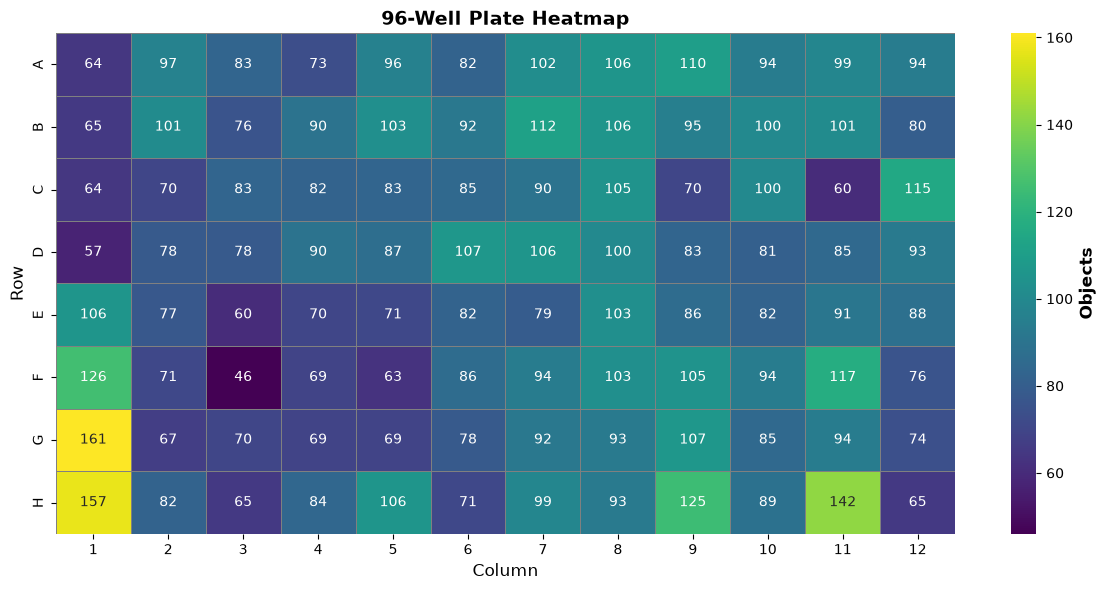

In [7]:
# Lazy import for the same reason as the processing imports above
from czitools.analysis_tools.plotting import create_well_plate_heatmap

# Create and display heatmap visualization using the dedicated function
fig = create_well_plate_heatmap(
    results=results_obj,
    num_rows=8,  # Standard 384-well plate
    num_cols=12,  # Standard 384-well plate
    title="96-Well Plate Heatmap",
    parameter="Objects",
    cmap="viridis",
    figsize=(12, 6),
    fmt=".0f",
)

plt.show()
